## Analyzing EOIR data - Detroit immigration court

In [5]:
import pandas as pd

df = pd.read_excel('detroit_court_cases.xlsx', sheet_name='data')
df.head()

,idncase,case_priority,sex,birth_year,nationality,language,state,county,place,date_of_entry,...,appeal_type,appeal_filed_by,appeal_filed_date,e27_date,custody_at_appeal,bia_decision,bia_decision_type,bia_decision_date,first_hearing_location_code,last_hearing_location_code
0,8833705,Not Applicable,Female,1988.0,Nigeria,English,IN,Marion,Indianapolis City,2018-02-25,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaT,IAD,IAD
1,8833758,Not Applicable,Female,2016.0,Nigeria,English,IN,Marion,Indianapolis City,2018-02-25,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaT,IAD,IAD
2,8815721,Not Applicable,Female,1976.0,Mexico,Spanish,MI,Macomb,New Haven Village,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaT,IAD,IAD
3,11764602,Not Applicable,Female,1983.0,Mexico,Spanish,MI,Kent,Grand Rapids City,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaT,DET,DET
4,8839165,Not Applicable,Female,1984.0,Stateless - Alien Unable To Name A Country,Arabic,MI,Macomb,Sterling Heights City,2016-09-05,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaT,DET,DET


**Key variables:** date, judge, case outcomes

In [6]:
df.columns 

Index(['idncase', 'case_priority', 'sex', 'birth_year', 'nationality',
       'language', 'state', 'county', 'place', 'date_of_entry', 'nta_date',
       'charge_section_1', 'charge_section_2', 'charge_section_3',
       'charge_section_4', 'first_court', 'final_court', 'first_judge_name',
       'last_judge_name', 'deported_1', 'deported_2', 'e28_date',
       'represented', 'in_absentia', 'ij_final_date', 'final_completion_date',
       'custody', 'detention_start_1', 'detention_end_1', 'detention_start_2',
       'detention_end_2', 'detention_start_3', 'detention_end_3',
       'detention_start_4', 'detention_end_4', 'bond_court', 'bond_judge_name',
       'bond_hearing_request_date', 'bond_completion_date', 'bond_decision',
       'initial_bond_amount', 'new_bond_amount', 'asylum_claim_type',
       'asylum_application', 'withholding_application', 'cat_application',
       'adjustment_application', 'non_lpr_cancellation_application',
       'lpr_cancellation_application', 'any_reli

In [7]:
small_df = df[['idncase', 'last_judge_name', 'ij_final_date', 'case_outcome']]
small_df.head()

,idncase,last_judge_name,ij_final_date,case_outcome
0,8833705,IAD Judge,2020-03-05,Failure To Prosecute (DHS Cases Only)
1,8833758,IAD Judge,2020-03-05,Failure To Prosecute (DHS Cases Only)
2,8815721,IAD Judge,2020-03-05,Failure To Prosecute (DHS Cases Only)
3,11764602,"Paruch, David H.",2024-05-07,Failure To Prosecute (DHS Cases Only)
4,8839165,"Simons, Ian R.",2019-05-30,Failure To Prosecute (DHS Cases Only)


**Case outcome by month**

In [32]:
small_df['date'] = pd.to_datetime(small_df['ij_final_date'])
small_df['month_year'] = small_df['date'].dt.strftime('%Y-%m')

by_month = small_df.groupby(['month_year', 'case_outcome']).size().reset_index().rename({
    'case_outcome': 'outcome',
    0: 'num_cases'
}, axis=1
)

In [33]:
by_month_pivot = by_month.pivot_table(values='num_cases', index='month_year', columns='outcome').reset_index()
by_month_pivot = by_month_pivot.fillna(0)

In [34]:
#Format pivot table
keep_outcomes = ['Relief Granted', 'Remove', 'Voluntary Departure']
outcome_cols = [col for col in by_month_pivot.columns if col != 'month_year']
keep_outcomes = [col for col in keep_outcomes if col in outcome_cols]
other_outcomes = [col for col in outcome_cols if col not in keep_outcomes]

by_month_pivot = by_month_pivot.set_index('month_year').copy()
by_month_pivot['Other'] = by_month_pivot[other_outcomes].sum(axis=1).fillna(0)
by_month_pivot = by_month_pivot[keep_outcomes + ['Other']].fillna(0)

In [35]:
by_month_pivot.sort_values('month_year')

outcome,Relief Granted,Remove,Voluntary Departure,Other
month_year,,,,
1997-10,0.0,11.0,0.0,0.0
1997-11,2.0,19.0,0.0,0.0
1997-12,1.0,14.0,1.0,1.0
1998-01,1.0,41.0,0.0,8.0
1998-02,1.0,22.0,0.0,48.0
...,...,...,...,...
2026-01,4.0,429.0,134.0,189.0
2026-02,4.0,379.0,143.0,201.0
2026-03,12.0,527.0,161.0,194.0


In [36]:
# add Total and percent columns to by_month_pivot
by_month_pivot['Total'] = by_month_pivot.sum(axis=1)

for src_col, pct_col in [
    ('Relief Granted', 'Relief %'),
    ('Remove', 'Remove %'),
    ('Voluntary Departure', 'Voluntary Departure %'),
]:
    by_month_pivot[pct_col] = 0.0
    mask = by_month_pivot['Total'] != 0
    if src_col in by_month_pivot.columns:
        by_month_pivot.loc[mask, pct_col] = (by_month_pivot.loc[mask, src_col] / by_month_pivot.loc[mask, 'Total']) * 100

# round percentage columns
by_month_pivot[['Relief %', 'Remove %', 'Voluntary Departure %']] = by_month_pivot[['Relief %', 'Remove %', 'Voluntary Departure %']].round(1)

by_month_pivot.head()

outcome,Relief Granted,Remove,Voluntary Departure,Other,Total,Relief %,Remove %,Voluntary Departure %
month_year,,,,,,,,
1997-10,0.0,11.0,0.0,0.0,11.0,0.0,100.0,0.0
1997-11,2.0,19.0,0.0,0.0,21.0,9.5,90.5,0.0
1997-12,1.0,14.0,1.0,1.0,17.0,5.9,82.4,5.9
1998-01,1.0,41.0,0.0,8.0,50.0,2.0,82.0,0.0
1998-02,1.0,22.0,0.0,48.0,71.0,1.4,31.0,0.0


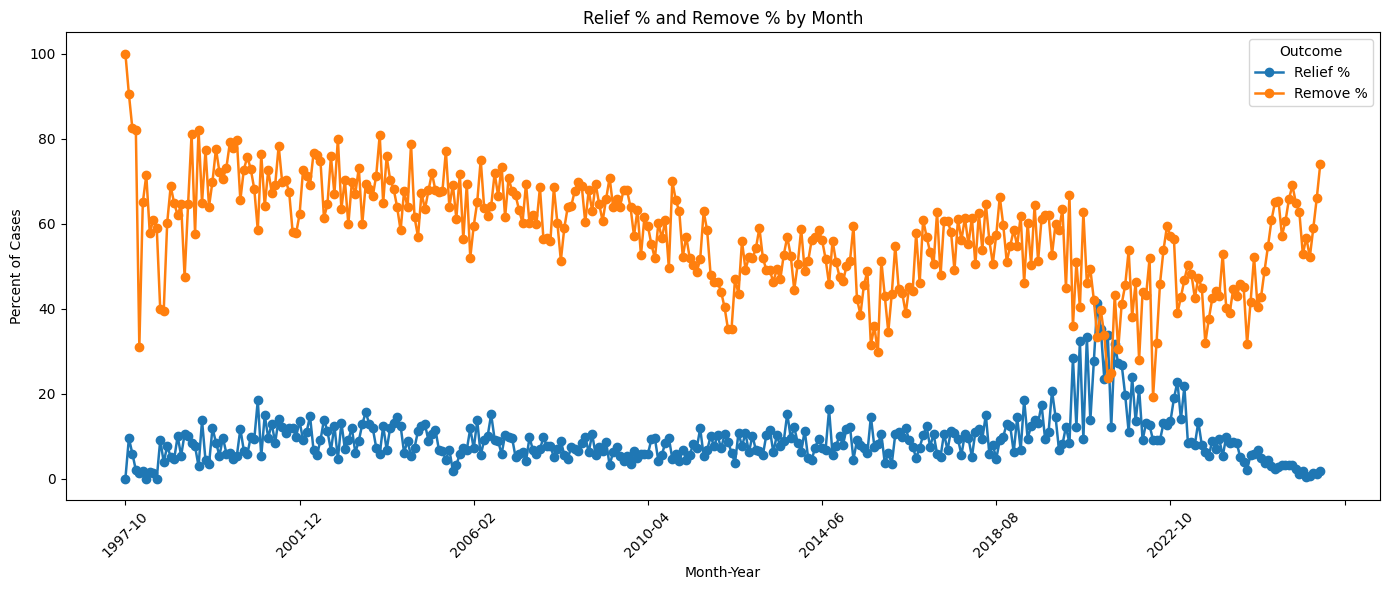

In [37]:
import matplotlib.pyplot as plt

ax = by_month_pivot[['Relief %', 'Remove %']].plot(
    kind='line',
    figsize=(14, 6),
    marker='o',
    linewidth=1.8
)

ax.set_title('Relief % and Remove % by Month')
ax.set_xlabel('Month-Year')
ax.set_ylabel('Percent of Cases')
ax.legend(title='Outcome')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Judge-by-judge analysis**

In [43]:
current_judges = ['Cooper, Christopher', 'Gundlach, Robert', 'Hansen, Katherine L.', 'Jebson, Mark J.', 'Kallas, Denise',
'Krishnan, Jill K.', 'Moriarty, John', 'Simons, Ian R.']

current_judges_df = df[df['last_judge_name'].isin(current_judges)]

current_judges_df['last_judge_name'].unique()

<StringArray>
[      'Simons, Ian R.', 'Hansen, Katherine L.',  'Cooper, Christopher',
     'Gundlach, Robert',      'Jebson, Mark J.',    'Krishnan, Jill K.',
       'Kallas, Denise',       'Moriarty, John']
Length: 8, dtype: str

In [44]:
import pandas as pd

# monthly judge-level percent table and a summary
jm = small_df[small_df['last_judge_name'].isin(current_judges)].copy()

g = jm.groupby(['month_year', 'last_judge_name', 'case_outcome']).size().reset_index(name='num_cases')
pivot = g.pivot_table(values='num_cases', index=['month_year', 'last_judge_name'], columns='case_outcome', fill_value=0)

# safe column access
relief = pivot['Relief Granted'] if 'Relief Granted' in pivot.columns else pd.Series(0, index=pivot.index)
remove = pivot['Remove'] if 'Remove' in pivot.columns else pd.Series(0, index=pivot.index)
total = pivot.sum(axis=1)

judge_monthly_pct = (
    pd.DataFrame({
        'month_year': [idx[0] for idx in pivot.index],
        'last_judge_name': [idx[1] for idx in pivot.index],
        'Relief Granted': relief.values,
        'Remove': remove.values,
        'Total': total.values,
    })
    .assign(
        Relief_Pct=lambda df: (df['Relief Granted'] / df['Total'].replace(0, pd.NA)) * 100,
        Remove_Pct = lambda df: (df['Remove'] / df['Total'].replace(0, pd.NA)) * 100
    )
    .fillna({'Relief_Pct': 0, 'Remove_Pct': 0})
    .astype({'Relief_Pct':'float', 'Remove_Pct':'float'})
    .round({'Relief_Pct':1, 'Remove_Pct':1})
    .sort_values(['last_judge_name','month_year'])
    .reset_index(drop=True)
)

# summary by judge across months
judge_summary = judge_monthly_pct.groupby('last_judge_name').agg(
    months_recorded = ('month_year','nunique'),
    total_cases = ('Total','sum'),
    avg_relief_pct = ('Relief_Pct','mean'),
    avg_remove_pct = ('Remove_Pct','mean'),
    median_relief_pct = ('Relief_Pct','median'),
    median_remove_pct = ('Remove_Pct','median')
).round(1).sort_values('last_judge_name')

# show results
judge_monthly_pct.head(), judge_summary

(  month_year       last_judge_name  Relief Granted  Remove  Total  Relief_Pct  \
 0    2026-04   Cooper, Christopher             0.0    20.0   24.0         0.0   
 1    2026-05   Cooper, Christopher             1.0    60.0   66.0         1.5   
 2    2016-08      Gundlach, Robert             0.0     0.0    1.0         0.0   
 3    2003-03  Hansen, Katherine L.             0.0     0.0    1.0         0.0   
 4    2004-04  Hansen, Katherine L.             0.0     1.0    1.0         0.0   
 
    Remove_Pct  
 0        83.3  
 1        90.9  
 2         0.0  
 3         0.0  
 4       100.0  ,
                       months_recorded  total_cases  avg_relief_pct  \
 last_judge_name                                                      
 Cooper, Christopher                 2         90.0             0.8   
 Gundlach, Robert                    1          1.0             0.0   
 Hansen, Katherine L.               51       3132.0             5.1   
 Jebson, Mark J.                   126       744

In [47]:
small_current_judges = current_judges_df[['idncase', 'last_judge_name', 'ij_final_date', 'case_outcome', 'nationality', 'language', 'represented', 'custody']]

In [48]:
small_current_judges.to_csv('current_detroit_judges.csv')